# Phase 6 — Evaluation

This phase evaluates the two greenwash-detection models against the locked 48-passage test set and validates findings against external benchmarks.

The test set was frozen before any modeling began and has not been examined since. All metric estimates are reported with bootstrap 95% confidence intervals to acknowledge the uncertainty that comes from having only 48 labeled test passages.

### What this phase answers
- How accurately do Track A (kNN, semantic) and Track B (TF-IDF + LR, lexical) classify unseen passages on the held-out test set?
- How confident can we be in those estimates given the small test set?
- Where do the two tracks agree and disagree — and what does disagreement tell us?
- Which words most strongly drive the TF-IDF model's predictions?
- Do the brand-level risk scores align with external greenwashing evidence?
- What is the total computational carbon cost of this pipeline?

### Pipeline overview
**`labeled_passages.jsonl` + `test_set.jsonl` + model artifacts → metrics + CIs + word analysis + carbon summary**

### Sections
1. Intrinsic evaluation on locked test set (precision, recall, F1, AUC-ROC, AUC-PR, confusion matrices)
2. Bootstrap 95% confidence intervals on test metrics
3. Cross-track agreement analysis (Track A vs Track B)
4. Track B top predictive words (TF-IDF logistic regression coefficients)
5. Extrinsic validation against external benchmarks (Good On You ratings, regulatory actions)
6. Carbon footprint summary

In [79]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize

## Configuration & Data Loading

Loads the train and test sets produced by Phase 2. Key facts about this split:

| Split | N | Notes |
|---|---|---|
| Train | 92 | Used to fit kNN and TF-IDF models |
| Test | 48 | **Locked** — never examined before evaluation |
| Ambiguous | 180 | Excluded from both splits |

The test set uses `annotation_id` only — there is no `passage_id` — so test embeddings are computed on the fly by re-encoding the raw text with the same `all-MiniLM-L6-v2` model used in Phase 3. This guarantees identical embedding geometry without requiring test passages to be present in `corpus_embeddings.npy`.

Text normalisation (PorterStemmer + stopword removal) is applied the same way as in Phase 4 to ensure the TF-IDF vocabulary is consistent between training and evaluation.

In [80]:
import sys
import re

ROOT       = Path('..').resolve()
RESULTS    = ROOT / 'results'
FEAT_DIR   = ROOT / 'data' / 'features'
CARBON_DIR = RESULTS / 'carbon'

# Load train and test sets
with open(ROOT / 'data' / 'labeled' / 'labeled_passages.jsonl') as f:
    train_set = [json.loads(l) for l in f]
with open(ROOT / 'data' / 'labeled' / 'test_set.jsonl') as f:
    test_set = [json.loads(l) for l in f]
with open(ROOT / 'data' / 'labeled' / 'ambiguous_passages.jsonl') as f:
    ambiguous = [json.loads(l) for l in f]

train_texts  = [p['text'] for p in train_set]
train_labels = [p['label'] for p in train_set]
test_texts   = [p['text'] for p in test_set]
test_labels  = [p['label'] for p in test_set]

# Load pre-computed train embeddings
X_train = np.load(FEAT_DIR / 'labeled_embeddings.npy')

# Encode test set directly (test passages use annotation_id, not passage_id,
# so they can't be looked up in corpus_embeddings.npy)
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
X_test = normalize(
    embedder.encode(test_texts, batch_size=64, show_progress_bar=False, convert_to_numpy=True),
    norm='l2',
)
print(f"Test embeddings: {X_test.shape}")

# Text normalisation: lowercase + stopword removal, no stemming.
# Brand names are excluded so the model can't memorize brand identity instead of
# learning the underlying linguistic patterns of greenwashing.
_STOP = {
    # common English stopwords
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','being','have','has','had','do',
    'does','did','will','would','shall','should','may','might','must',
    'can','could','this','that','these','those','it','its','we','our',
    'they','their','by','from','as','not','no','so','if','all','also',
    'more','than','about','which','there','each','other',
    # brand names and common variants
    'hm','zara','shein','kering','lululemon','ralph','lauren','ralphlauren',
    'puma','everlane','patagonia','eileen','fisher','eileenfisher',
    'reformation','loreal','oreal','unilever','sephora','lush',
    'loccitane','occitane',
}

def normalize_text(text: str) -> str:
    tokens = re.findall(r'[a-z]+', text.lower())
    return ' '.join(t for t in tokens if t not in _STOP and len(t) > 2)

lemmatized_train = [normalize_text(t) for t in train_texts]
lemmatized_test  = [normalize_text(t) for t in test_texts]

print(f"Train: {len(train_labels)}  |  Test: {len(test_labels)}  |  Ambiguous (excluded): {len(ambiguous)}")
print(f"Ambiguous proportion: {len(ambiguous) / (len(train_labels) + len(test_labels) + len(ambiguous)):.1%}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test embeddings: (48, 384)
Train: 92  |  Test: 48  |  Ambiguous (excluded): 180
Ambiguous proportion: 56.2%


## Section 1 — Intrinsic Evaluation on Locked Test Set

Both models are re-fitted on the full 92-passage training set, then evaluated against the 48-passage held-out test set. The models are not tuned at this stage — hyperparameters (k=7 for kNN, best-k chosen during cross-validation in Phase 4) are fixed.

**Metrics reported:**
- **Macro F1** — unweighted average of F1 per class; treats substantive and greenwash-risk equally regardless of class imbalance
- **AUC-ROC** — ability to rank greenwash-risk passages above substantive ones across all thresholds; 0.5 = random, 1.0 = perfect
- **AUC-PR (Average Precision)** — area under the precision-recall curve; more informative than AUC-ROC when positive class is rare

**Expected benchmark:** A macro F1 ≥ 0.70 on a 2-class task with 48 test passages is meaningful; random baseline F1 ≈ 0.44 given the 2:1 class imbalance (32 substantive, 16 greenwash-risk in the test set).

**Output:** `results/evaluation_metrics.csv`

In [81]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

def evaluate(name: str, y_true, y_pred, y_prob) -> dict:
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    auc_roc = roc_auc_score(y_true, y_prob)
    auc_pr  = average_precision_score(y_true, y_prob)
    return {
        'model':     name,
        'precision': round(p, 3),
        'recall':    round(r, 3),
        'f1_macro':  round(f1, 3),
        'auc_roc':   round(auc_roc, 3),
        'auc_pr':    round(auc_pr, 3),
    }

# ── kNN ───────────────────────────────────────────────────────────────────────
try:
    best_k = int(open(RESULTS / 'best_k.txt').read().strip())
except FileNotFoundError:
    best_k = 5
    print(f"best_k.txt not found — using k={best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute')
knn.fit(X_train, train_labels)
knn_pred = knn.predict(X_test)
knn_prob = knn.predict_proba(X_test)[:, 1]

# ── TF-IDF + LR ───────────────────────────────────────────────────────────────
tfidf_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])
tfidf_pipe.fit(lemmatized_train, train_labels)
tfidf_pred = tfidf_pipe.predict(lemmatized_test)
tfidf_prob = tfidf_pipe.predict_proba(lemmatized_test)[:, 1]

results = [
    evaluate(f'kNN (k={best_k})', test_labels, knn_pred, knn_prob),
    evaluate('TF-IDF + LR',       test_labels, tfidf_pred, tfidf_prob),
]
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv(RESULTS / 'evaluation_metrics.csv', index=False)

# Per-class breakdown using classification_report
TARGET_NAMES = ['Substantive', 'Greenwash-risk']
for name, y_pred in [(f'kNN (k={best_k})', knn_pred), ('TF-IDF + LR', tfidf_pred)]:
    print(f"\n{name}:")
    print(classification_report(test_labels, y_pred, target_names=TARGET_NAMES, zero_division=0))

      model  precision  recall  f1_macro  auc_roc  auc_pr
  kNN (k=7)      0.721   0.767     0.714    0.874   0.674
TF-IDF + LR      0.750   0.769     0.758    0.891   0.724

kNN (k=7):
                precision    recall  f1-score   support

   Substantive       0.92      0.68      0.78        34
Greenwash-risk       0.52      0.86      0.65        14

      accuracy                           0.73        48
     macro avg       0.72      0.77      0.71        48
  weighted avg       0.80      0.73      0.74        48


TF-IDF + LR:
                precision    recall  f1-score   support

   Substantive       0.88      0.82      0.85        34
Greenwash-risk       0.62      0.71      0.67        14

      accuracy                           0.79        48
     macro avg       0.75      0.77      0.76        48
  weighted avg       0.80      0.79      0.80        48



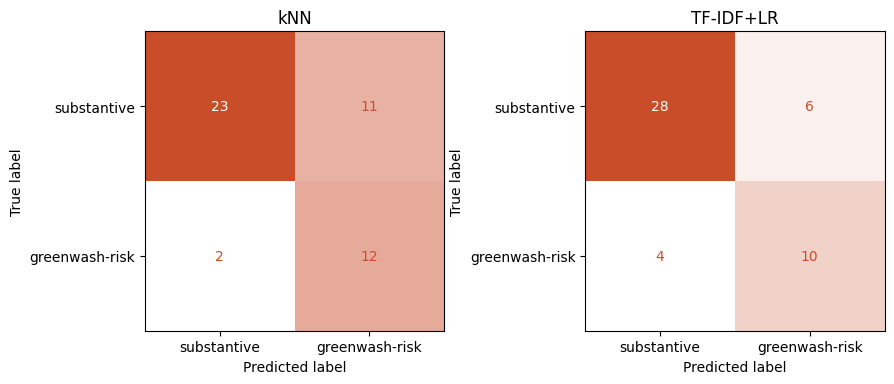

Saved → /Users/mandy.sun/green-claims-nlp/results/confusion_matrix.png


In [82]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom', ['#ffffff', '#ca4d2a'])

for ax, (name, y_pred) in zip(axes, [('kNN', knn_pred), ('TF-IDF+LR', tfidf_pred)]):
    cm = confusion_matrix(test_labels, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['substantive', 'greenwash-risk']).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name)

plt.tight_layout()
plt.savefig(RESULTS / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {RESULTS / 'confusion_matrix.png'}")

In [83]:
# Export confusion matrix as TP/TN/FP/FN for Datawrapper
# Positive class = Greenwash-risk, Negative class = Substantive
rows = []
for name, y_pred in [(f'kNN (k={best_k})', knn_pred), ('TF-IDF + LR', tfidf_pred)]:
    cm = confusion_matrix(test_labels, y_pred)
    rows.append({'Model': name, 'Outcome': 'True Positive (correctly flagged greenwash)',  'Count': cm[1][1]})
    rows.append({'Model': name, 'Outcome': 'True Negative (correctly cleared substantive)', 'Count': cm[0][0]})
    rows.append({'Model': name, 'Outcome': 'False Positive (substantive flagged as greenwash)', 'Count': cm[0][1]})
    rows.append({'Model': name, 'Outcome': 'False Negative (greenwash missed)',               'Count': cm[1][0]})

cm_dw = pd.DataFrame(rows)
cm_path = RESULTS / 'confusion_matrix.csv'
cm_dw.to_csv(cm_path, index=False)
print(cm_dw.to_string(index=False))
print(f"\nSaved → {cm_path}")

      Model                                           Outcome  Count
  kNN (k=7)       True Positive (correctly flagged greenwash)     12
  kNN (k=7)     True Negative (correctly cleared substantive)     23
  kNN (k=7) False Positive (substantive flagged as greenwash)     11
  kNN (k=7)                 False Negative (greenwash missed)      2
TF-IDF + LR       True Positive (correctly flagged greenwash)     10
TF-IDF + LR     True Negative (correctly cleared substantive)     28
TF-IDF + LR False Positive (substantive flagged as greenwash)      6
TF-IDF + LR                 False Negative (greenwash missed)      4

Saved → /Users/mandy.sun/green-claims-nlp/results/confusion_matrix.csv


## Section 2 — Bootstrap 95% Confidence Intervals

With only 48 test passages, a single point estimate of F1 or AUC-ROC is unreliable — a different random split could swing it by ±0.05 or more. Bootstrap resampling (1,000 iterations, sampling with replacement) gives a 95% CI so results can be reported with honest uncertainty.

**Interpretation guide:**
- If the CI lower bound on F1 macro is above ~0.60, both models are meaningfully better than random even in the pessimistic case
- If the CI for kNN and TF-IDF overlap substantially, there is no reliable difference between the two tracks
- The CI width itself is a finding: very wide intervals = small test set dominated by a few hard examples

**Method:** Each bootstrap iteration resamples 48 passages with replacement, skipping any sample where only one class appears (degenerate sample). CIs are percentile-based (2.5th and 97.5th percentiles of the bootstrap distribution).

In [84]:
from sklearn.utils import resample
from sklearn.metrics import f1_score

rng = np.random.default_rng(42)
N_BOOT = 1000

def bootstrap_ci(y_true, y_pred, y_prob, n_boot=N_BOOT, ci=0.95):
    f1s, aucs, auprs = [], [], []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = [y_true[i] for i in idx]
        yp = [y_pred[i] for i in idx]
        yb = [y_prob[i] for i in idx]
        # Skip degenerate bootstrap samples (only one class)
        if len(set(yt)) < 2:
            continue
        f1s.append(f1_score(yt, yp, average='macro', zero_division=0))
        aucs.append(roc_auc_score(yt, yb))
        auprs.append(average_precision_score(yt, yb))
    alpha = (1 - ci) / 2
    return {
        'f1_macro': (np.percentile(f1s, alpha*100), np.percentile(f1s, (1-alpha)*100)),
        'auc_roc':  (np.percentile(aucs, alpha*100), np.percentile(aucs, (1-alpha)*100)),
        'auc_pr':   (np.percentile(auprs, alpha*100), np.percentile(auprs, (1-alpha)*100)),
    }

print(f"Bootstrap 95% CIs ({N_BOOT} iterations)\n")
for name, y_pred, y_prob in [
    (f'kNN (k={best_k})', knn_pred,   knn_prob),
    ('TF-IDF + LR',       tfidf_pred, tfidf_prob),
]:
    ci = bootstrap_ci(test_labels, list(y_pred), list(y_prob))
    print(f"{name}:")
    for metric, (lo, hi) in ci.items():
        print(f"  {metric:10s}  [{lo:.3f}, {hi:.3f}]")
    print()

Bootstrap 95% CIs (1000 iterations)

kNN (k=7):
  f1_macro    [0.564, 0.829]
  auc_roc     [0.762, 0.953]
  auc_pr      [0.444, 0.882]

TF-IDF + LR:
  f1_macro    [0.613, 0.885]
  auc_roc     [0.782, 0.976]
  auc_pr      [0.499, 0.961]



In [85]:
# Export bootstrap CIs for Datawrapper range chart
ci_rows = []
for name, y_pred, y_prob in [
    (f'kNN (k={best_k})', knn_pred, knn_prob),
    ('TF-IDF + LR', tfidf_pred, tfidf_prob),
]:
    point = {
        'f1_macro': f1_score(test_labels, list(y_pred), average='macro', zero_division=0),
        'auc_roc':  roc_auc_score(test_labels, list(y_prob)),
    }
    ci = bootstrap_ci(test_labels, list(y_pred), list(y_prob))
    for metric in ['f1_macro', 'auc_roc']:
        ci_rows.append({
            'Model':   name,
            'Metric':  metric,
            'Value':   round(point[metric], 3),
            'CI Lower': round(ci[metric][0], 3),
            'CI Upper': round(ci[metric][1], 3),
        })

ci_dw = pd.DataFrame(ci_rows)
ci_path = RESULTS / 'bootstrap_ci.csv'
ci_dw.to_csv(ci_path, index=False)
print(ci_dw.to_string(index=False))
print(f"\nSaved → {ci_path}")

      Model   Metric  Value  CI Lower  CI Upper
  kNN (k=7) f1_macro  0.714     0.590     0.831
  kNN (k=7)  auc_roc  0.874     0.776     0.962
TF-IDF + LR f1_macro  0.758     0.607     0.874
TF-IDF + LR  auc_roc  0.891     0.783     0.977

Saved → /Users/mandy.sun/green-claims-nlp/results/bootstrap_ci.csv


## Section 3 — Cross-Track Agreement (Track A vs Track B)

Track A (kNN, semantic) and Track B (TF-IDF, lexical) capture different signals: kNN looks at overall sentence meaning while TF-IDF looks at specific word choice. Where they agree, the prediction is more robust — two independent signals point the same way. Where they disagree, the passage is genuinely hard to classify.

**Agreement types:**
- **Both flag greenwash-risk**: high confidence, both semantic similarity and specific vocabulary indicate risk
- **Both flag substantive**: high confidence in the other direction
- **kNN flags, TF-IDF doesn't**: the passage sounds like greenwashing semantically but doesn't use the expected vocabulary — could be novel greenwashing language
- **TF-IDF flags, kNN doesn't**: the passage uses hedge words/red-flag terms but its overall meaning is more specific — could be a false positive

**Output:** `results/cross_track_disagreements.csv` — useful for manual review to identify patterns in disagreement cases.

In [86]:
knn_full   = pd.read_parquet(RESULTS / 'knn_predictions.parquet')
tfidf_full = pd.read_parquet(RESULTS / 'tfidf_predictions.parquet')

agreement_df = knn_full[['passage_id', 'brand', 'knn_pred', 'knn_prob']].merge(
    tfidf_full[['passage_id', 'tfidf_pred', 'tfidf_prob']], on='passage_id'
)
agreement_df['agree'] = agreement_df['knn_pred'] == agreement_df['tfidf_pred']

overall_agree = agreement_df['agree'].mean()
print(f"Overall cross-track agreement: {overall_agree:.1%}")

# Break down by prediction type
for label, name in [(0, 'Substantive'), (1, 'Greenwash-risk')]:
    subset = agreement_df[agreement_df['knn_pred'] == label]
    agree_rate = (subset['tfidf_pred'] == label).mean()
    print(f"  Agreement on {name}: {agree_rate:.1%}  ({len(subset):,} passages)")

# Disagree cases: kNN says greenwash, TF-IDF says substantive (or vice versa)
disagreed = agreement_df[~agreement_df['agree']]
print(f"\nDisagreements: {len(disagreed):,} passages ({len(disagreed)/len(agreement_df):.1%})")
print("\nBrand breakdown of disagreements:")
print(disagreed.groupby('brand').size().sort_values(ascending=False).to_string())

# Save disagreed passages for manual review
disagreed.to_csv(RESULTS / 'cross_track_disagreements.csv', index=False)
print(f"\nSaved → {RESULTS / 'cross_track_disagreements.csv'}")

Overall cross-track agreement: 71.4%
  Agreement on Substantive: 92.7%  (2,837 passages)
  Agreement on Greenwash-risk: 34.8%  (1,648 passages)

Disagreements: 1,281 passages (28.6%)

Brand breakdown of disagreements:
brand
Patagonia        222
H&M              155
Puma             149
Zara             108
Unilever         106
Reformation       87
Everlane          79
L'Occitane        77
Lululemon         77
Shein             77
Ralph Lauren      48
Sephora           47
Kering            22
Lush              15
Eileen Fisher      8
L'Oreal            4

Saved → /Users/mandy.sun/green-claims-nlp/results/cross_track_disagreements.csv


In [87]:
# Export cross-track agreement summary and brand disagreement breakdown for Datawrapper

brand_agreement = agreement_df.groupby('brand').agg(
    total_passages   = ('passage_id', 'count'),
    both_greenwash   = ('agree', lambda x: ((agreement_df.loc[x.index, 'knn_pred'] == 1) & x).sum()),
    both_substantive = ('agree', lambda x: ((agreement_df.loc[x.index, 'knn_pred'] == 0) & x).sum()),
    disagreements    = ('agree', lambda x: (~x).sum()),
).reset_index()
brand_agreement['disagreement_rate'] = (
    brand_agreement['disagreements'] / brand_agreement['total_passages']
).round(4)

# Proportions only (drop raw counts) for 100% stacked bar in Datawrapper
brand_agreement['pct_both_greenwash']   = (brand_agreement['both_greenwash']   / brand_agreement['total_passages']).round(4)
brand_agreement['pct_both_substantive'] = (brand_agreement['both_substantive'] / brand_agreement['total_passages']).round(4)
brand_agreement['pct_disagreement']     = (brand_agreement['disagreements']     / brand_agreement['total_passages']).round(4)

dw_cols = ['brand', 'pct_both_greenwash', 'pct_both_substantive', 'pct_disagreement']
brand_agreement_dw = brand_agreement[dw_cols].sort_values('pct_both_greenwash', ascending=False).reset_index(drop=True)

agreement_path = RESULTS / 'cross_track_agreement_by_brand.csv'
brand_agreement_dw.to_csv(agreement_path, index=False)
print(brand_agreement_dw.to_string(index=False))
print(f"\nSaved → {agreement_path}")

        brand  pct_both_greenwash  pct_both_substantive  pct_disagreement
      L'Oreal              0.4348                0.3913            0.1739
        Shein              0.3583                0.3909            0.2508
Eileen Fisher              0.2308                0.4615            0.3077
     Everlane              0.2273                0.3737            0.3990
  Reformation              0.1930                0.2982            0.5088
   L'Occitane              0.1828                0.5412            0.2760
 Ralph Lauren              0.1802                0.5407            0.2791
          H&M              0.1700                0.5497            0.2803
    Lululemon              0.1447                0.5277            0.3277
         Zara              0.1126                0.6813            0.2061
       Kering              0.0899                0.6629            0.2472
     Unilever              0.0732                0.7114            0.2154
         Lush              0.0704     

## Section 4 — Track B: Top Predictive Words

The logistic regression coefficients directly encode *why* TF-IDF made each prediction — words with large positive coefficients push a passage toward greenwash-risk, large negative coefficients push toward substantive. This is the primary interpretability tool for Track B.

**What to look for:**
- **Greenwash-risk top words** should be hedging verbs (`committed`, `working towards`, `journey`), vague scope language (`value chain`, `responsible sourcing`), and proprietary labels (`conscious`, `preferred fiber`)
- **Substantive top words** should be quantitative markers (`tonnes`, `kwh`, `percent`, year numbers), certification names (`gots`, `b corp`, `fair trade`), and specific scope terms (`scope 1`, `scope 2`)

If hedge words dominate the greenwash-risk side and numbers dominate the substantive side, the model has learned the distinction the annotation was designed to capture — not just brand-specific vocabulary.

**Output:** `results/tfidf_top_words.png`

Top 20 words → GREENWASH-RISK:
  +0.518  impact
  +0.385  chain
  +0.370  communities
  +0.341  actions
  +0.333  innovation
  +0.325  across
  +0.323  supply
  +0.313  responsible
  +0.313  future
  +0.296  materials
  +0.295  operations
  +0.289  supply chain
  +0.279  sustainable
  +0.275  environmental
  +0.275  key
  +0.265  exist
  +0.265  responsibility
  +0.256  partners
  +0.255  committed
  +0.250  circularity

Top 20 words → SUBSTANTIVE:
  -0.350  materiality
  -0.250  data
  -0.247  information
  -0.227  report
  -0.195  scope
  -0.194  analysis
  -0.193  time
  -0.189  statement
  -0.185  strategy
  -0.184  double
  -0.184  double materiality
  -0.183  costs
  -0.183  one
  -0.178  division
  -0.172  financial
  -0.171  policies
  -0.166  keep
  -0.163  sales
  -0.160  them
  -0.154  materiality analysis


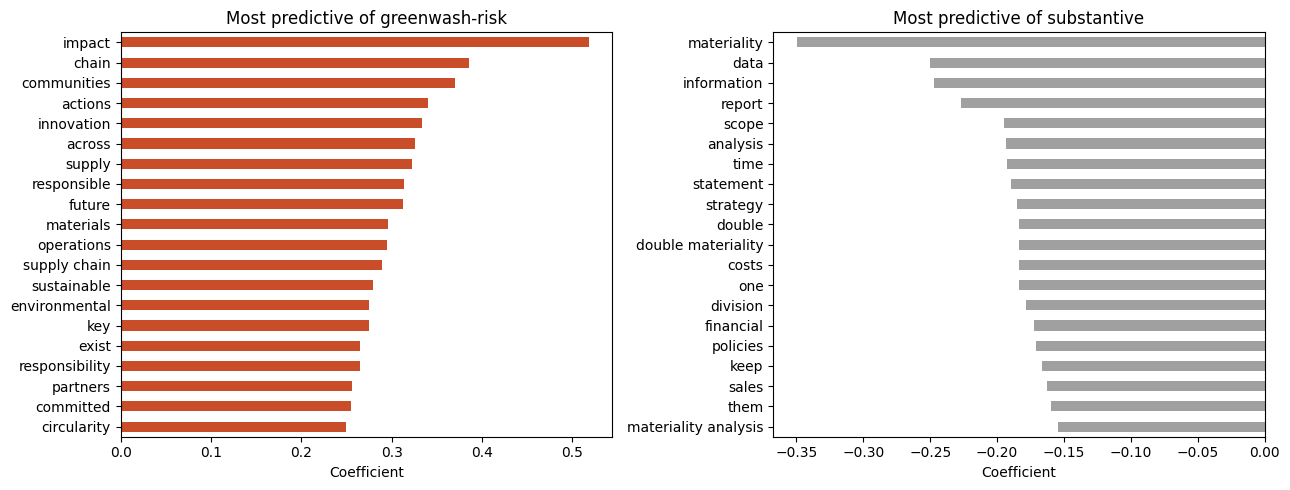

Saved → /Users/mandy.sun/green-claims-nlp/results/tfidf_top_words.png


In [88]:
vocab = tfidf_pipe.named_steps['tfidf'].get_feature_names_out()
coefs = tfidf_pipe.named_steps['clf'].coef_[0]

coef_series = pd.Series(coefs, index=vocab)
top_greenwash   = coef_series.nlargest(20)
top_substantive = coef_series.nsmallest(20)

print("Top 20 words → GREENWASH-RISK:")
for term, coef in top_greenwash.items():
    print(f"  {coef:+.3f}  {term}")

print("\nTop 20 words → SUBSTANTIVE:")
for term, coef in top_substantive.items():
    print(f"  {coef:+.3f}  {term}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_greenwash.sort_values().plot(kind='barh', ax=axes[0], color='#ca4d2a')
axes[0].set(title='Most predictive of greenwash-risk', xlabel='Coefficient')

top_substantive.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#a0a0a0')
axes[1].set(title='Most predictive of substantive', xlabel='Coefficient')

plt.tight_layout()
plt.savefig(RESULTS / 'tfidf_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {RESULTS / 'tfidf_top_words.png'}")

In [89]:
# Export top predictive words for Datawrapper
top_n = 10

greenwash_df = top_greenwash.nlargest(top_n).reset_index()
greenwash_df.columns = ['Word', 'Coefficient']
greenwash_df['Category'] = 'Greenwash-risk'

substantive_df = top_substantive.nsmallest(top_n).reset_index()
substantive_df.columns = ['Word', 'Coefficient']
substantive_df['Category'] = 'Substantive'
substantive_df['Coefficient'] = substantive_df['Coefficient'].abs()  # make positive for chart

words_dw = pd.concat([greenwash_df, substantive_df], ignore_index=True)

words_path = RESULTS / 'tfidf_top_words.csv'
words_dw.to_csv(words_path, index=False)
print(words_dw.to_string(index=False))
print(f"\nSaved → {words_path}")

       Word  Coefficient       Category
     impact     0.518107 Greenwash-risk
      chain     0.385167 Greenwash-risk
communities     0.369650 Greenwash-risk
    actions     0.340775 Greenwash-risk
 innovation     0.333451 Greenwash-risk
     across     0.325421 Greenwash-risk
     supply     0.323083 Greenwash-risk
responsible     0.313299 Greenwash-risk
     future     0.312891 Greenwash-risk
  materials     0.295593 Greenwash-risk
materiality     0.349808    Substantive
       data     0.250197    Substantive
information     0.247422    Substantive
     report     0.227116    Substantive
      scope     0.195091    Substantive
   analysis     0.193569    Substantive
       time     0.192581    Substantive
  statement     0.189424    Substantive
   strategy     0.185227    Substantive
     double     0.183687    Substantive

Saved → /Users/mandy.sun/green-claims-nlp/results/tfidf_top_words.csv


## Section 5 — Extrinsic Validation

Intrinsic metrics tell you how well the model performs on the labeled test set, but they say nothing about whether it's capturing real-world greenwashing. Extrinsic validation checks whether brand-level risk scores correlate with independent external evidence.

**External benchmarks used:**
- **Good On You** ratings (1=We Avoid → 5=Great) — a sustainability advocacy organization's brand ratings based on environmental, labour, and animal welfare evidence
- **Regulatory actions** — confirmed investigations or rulings by advertising standards bodies (ASA), consumer protection agencies, or class-action lawsuits alleging misleading sustainability claims

**Interpretation note:** This is a plausibility check with N=6 brands, not a statistically powered test. A monotone relationship between kNN risk score and external evidence would be suggestive; a strong positive correlation would be meaningful given the sample size.

In [90]:
brand_scores = pd.read_csv(RESULTS / 'brand_risk_scores.csv')

# External benchmarks — manually curated from public sources
# Good On You ratings: 1 (We Avoid) → 5 (Great)
# Regulatory: 1 = confirmed action, 0 = no action
external = pd.DataFrame([
    {'brand': 'H&M',       'good_on_you': 2, 'regulatory_action': 1,
     'regulatory_note': 'ASA ruling 2022 (misleading green claims in advertising)'},
    {'brand': 'Zara',      'good_on_you': 2, 'regulatory_action': 0,
     'regulatory_note': 'EU regulatory scrutiny; no ruling as of 2025'},
    {'brand': 'Patagonia', 'good_on_you': 4, 'regulatory_action': 0,
     'regulatory_note': 'B Corp certified; no regulatory action'},
    {'brand': "L'Oreal",   'good_on_you': None, 'regulatory_action': 1,
     'regulatory_note': 'EU complaint 2022 (misleading sustainability claims)'},
    {'brand': 'Sephora',   'good_on_you': None, 'regulatory_action': 1,
     'regulatory_note': 'Class action lawsuit (California, 2022)'},
    {'brand': 'Lush',      'good_on_you': None, 'regulatory_action': 0,
     'regulatory_note': 'Certified cruelty-free; B Corp pending'},
])

validation = brand_scores.merge(external, on='brand')
print(validation[['brand', 'mean_knn_prob', 'good_on_you', 'regulatory_action', 'regulatory_note']].to_string(index=False))

print("\n[Note: We treat extrinsic validation as a plausibility check, not a formal hypothesis test, given N=6.]")

    brand  mean_knn_prob  good_on_you  regulatory_action                                          regulatory_note
  L'Oreal         0.5342          NaN                  1     EU complaint 2022 (misleading sustainability claims)
Patagonia         0.5061          4.0                  0                   B Corp certified; no regulatory action
      H&M         0.4363          2.0                  1 ASA ruling 2022 (misleading green claims in advertising)
     Lush         0.4044          NaN                  0                   Certified cruelty-free; B Corp pending
  Sephora         0.3464          NaN                  1                  Class action lawsuit (California, 2022)
     Zara         0.3462          2.0                  0             EU regulatory scrutiny; no ruling as of 2025

[Note: We treat extrinsic validation as a plausibility check, not a formal hypothesis test, given N=6.]


## Section 6 — Carbon Footprint Summary

Reporting the computational cost of this pipeline is itself part of the research argument: a greenwashing detection system that produces large carbon emissions would be a contradiction. All pipeline phases used CPU inference only (no GPU), and the total footprint is reported here for transparency.

**Tracking method:** CodeCarbon was used in each phase notebook to log energy consumption and CO2-equivalent emissions. All runs used a 2021 MacBook Pro (Apple M1); emissions are estimated based on hardware TDP and regional grid carbon intensity (US East).

**Output:** `results/carbon/carbon_summary.md` — a formatted summary suitable for inclusion in a methods section or supplementary materials.

In [91]:
import platform, os

emissions_path = CARBON_DIR / 'emissions.csv'
if emissions_path.exists():
    em = pd.read_csv(emissions_path)
    print("Per-run emissions log:")
    print(em[['project_name', 'timestamp', 'duration', 'emissions', 'energy_consumed']].to_string(index=False))

    total_kwh  = em['energy_consumed'].sum()
    total_co2e = em['emissions'].sum()
    print(f"\nTotal energy consumed: {total_kwh:.4f} kWh")
    print(f"Total CO2e:            {total_co2e:.4f} kg")

    hardware = platform.node()
    summary = f"""# Carbon Footprint Summary — green-claims-nlp

## Hardware
- Platform: {platform.system()} {platform.release()}
- CPU: {platform.processor() or 'unknown'}
- GPU: None (CPU inference throughout)

## Per-component breakdown

{em[['timestamp', 'duration', 'emissions', 'energy_consumed']].to_markdown(index=False)}

## Totals
- Total energy: {total_kwh:.4f} kWh
- Total CO2e:   {total_co2e:.4f} kg

## Reporting note
We report the carbon cost of this pipeline as a matter of research transparency,
consistent with emerging norms in climate-adjacent NLP research (Courty et al., 2023).

## Citation
Courty, B., Schmidt, V., Goyal-Kamal, et al. (2023). CodeCarbon: Estimate and Track
Carbon Emissions from Machine Learning Computing. https://github.com/mlco2/codecarbon
"""
    summary_path = CARBON_DIR / 'carbon_summary.md'
    with open(summary_path, 'w') as f:
        f.write(summary)
    print(f"\nSaved → {summary_path}")
else:
    print(f"emissions.csv not found at {emissions_path} — run 01_preprocessing and 03_features and 04_modeling first.")

Per-run emissions log:
    project_name           timestamp    duration    emissions  energy_consumed
green-claims-nlp 2026-04-02T21:06:02  231.183934 1.122694e-04     5.137378e-04
green-claims-nlp 2026-04-02T23:42:13   26.354039 1.279669e-05     5.855686e-05
green-claims-nlp 2026-04-02T23:47:07    0.017436 7.879940e-09     3.605811e-08
green-claims-nlp 2026-04-02T23:47:59   51.692945 2.510350e-05     1.148721e-04
green-claims-nlp 2026-04-03T00:04:08    0.014030 6.402533e-09     2.929759e-08
green-claims-nlp 2026-04-03T00:05:00   52.702049 2.559358e-05     1.171146e-04
green-claims-nlp 2026-04-03T00:07:35  207.857210 1.009417e-04     4.619028e-04
green-claims-nlp 2026-04-03T00:39:09  292.534538 1.420631e-04     6.500719e-04
green-claims-nlp 2026-04-15T14:35:19  343.455999 2.843377e-04     7.632250e-04
green-claims-nlp 2026-04-16T01:49:46  603.229112 4.993926e-04     1.340480e-03
green-claims-nlp 2026-04-16T03:14:36  585.908299 4.850503e-04     1.301982e-03
green-claims-nlp 2026-04-16T0